# Quadrant Analysis — Human (blind) vs Model (inst_blind)

Per-question accuracy comparison across four quadrants (threshold = 0.5).
Model mean averaged across all groups: VLM / LM-decoder / Backbone LLM.

In [8]:
import re, json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

BASE = Path('/home/david/Desktop/yuna/HPA')
sys.path.insert(0, str(BASE / 'analysis'))

from utils.vqa import VQAAnswerMapper, vqa_accuracy
from utils.normalize_korean import normalize_korean_answer
from utils.load_human import load_participants, flatten_to_df

mapper = VQAAnswerMapper()

VARIANT_ORDER = ['C', 'B', 'A']
CT_TO_VARIANT = {'question': 'C', 'weaker_object': 'B', 'pronominalized': 'A'}
GROUP_COLORS  = {'VLM': '#E91E63', 'LM-decoder': '#2196F3', 'Backbone LLM': '#FF9800'}

def _clean_answer(ans):
    return re.sub(r'<think>.*?</think>\s*', '', ans, flags=re.DOTALL).strip()

## 1. Load Data

In [9]:
s2 = pd.read_csv(BASE / 'experiment/s2_v2/s2.csv')[[
    'question_id','ent','op','ent_grp','op_grp','signal_score','acc_original']]
participants = load_participants(BASE, min_answers=300)
df = flatten_to_df(participants, mapper, s2, normalize_fn=normalize_korean_answer)
print(f'Human: {df.participant.nunique()} participants, {df.question_id.nunique()} questions')

ALL_MODELS = {
    'Qwen3-VL-8B':        (BASE / 'evaluation/logits/pretrained',            'Qwen3-VL-8B-Instruct'),
    'LLaVA-1.5-7B':       (BASE / 'evaluation/logits/pretrained',            'llava-1.5-7b-hf'),
    'LLaVA-Mistral':      (BASE / 'evaluation/logits/pretrained',            'llava-v1.6-mistral-7b-hf'),
    'LLaVA-Vicuna':       (BASE / 'evaluation/logits/pretrained',            'llava-v1.6-vicuna-7b-hf'),
    'LLaVA-1.5 (LM)':     (BASE / 'evaluation/logits/lm_decoder/pretrained', 'llava-1.5-7b-hf'),
    'LLaVA-Mistral (LM)': (BASE / 'evaluation/logits/lm_decoder/pretrained', 'llava-v1.6-mistral-7b-hf'),
    'LLaVA-Vicuna (LM)':  (BASE / 'evaluation/logits/lm_decoder/pretrained', 'llava-v1.6-vicuna-7b-hf'),
    'Qwen3-8B':           (BASE / 'evaluation/logits/backbone/pretrained',   'Qwen3-8B'),
}
MODEL_TYPE = {
    'Qwen3-VL-8B': 'VLM', 'LLaVA-1.5-7B': 'VLM', 'LLaVA-Mistral': 'VLM', 'LLaVA-Vicuna': 'VLM',
    'LLaVA-1.5 (LM)': 'LM-decoder', 'LLaVA-Mistral (LM)': 'LM-decoder', 'LLaVA-Vicuna (LM)': 'LM-decoder',
    'Qwen3-8B': 'Backbone LLM',
}

q_ids = set(df['question_id'].tolist())
acc_raw = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
for label, (rdir, mdir) in ALL_MODELS.items():
    path = rdir / mdir / 'vqa_1k_control_inst_blind.jsonl'
    if not path.exists(): continue
    for line in open(path):
        ex = json.loads(line)
        qid = int(ex['question_id'])
        if qid not in q_ids: continue
        gt = mapper.get_answers(qid)
        for ct, var in CT_TO_VARIANT.items():
            ans = _clean_answer(ex.get('generated_answers', {}).get(ct, ''))
            if ans and gt:
                acc_raw[label][qid][var].append(vqa_accuracy(ans, gt))

model_q_acc = {
    label: pd.DataFrame(
        [{'question_id': qid, **{v: float(np.mean(acc_raw[label][qid][v]))
                                  if acc_raw[label][qid][v] else np.nan
                                  for v in VARIANT_ORDER}}
         for qid in q_ids]
    ).set_index('question_id')
    for label in ALL_MODELS if label in acc_raw
}
print('Models loaded:', list(model_q_acc.keys()))

   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...


   ✓ Loaded 214354 VQA annotations
Human: 10 participants, 116 questions
Models loaded: ['Qwen3-VL-8B', 'LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Vicuna', 'LLaVA-1.5 (LM)', 'LLaVA-Mistral (LM)', 'LLaVA-Vicuna (LM)', 'Qwen3-8B']


## 2. Build Comparison Table & Quadrant Labels

In [10]:
h_acc = df.groupby(['question_id','variant'])['accuracy'].mean().unstack()[VARIANT_ORDER]
h_acc.columns = [f'human_{v}' for v in VARIANT_ORDER]

model_inst_mean_C = pd.concat(
    [mdf['C'].rename(l) for l, mdf in model_q_acc.items()], axis=1
).mean(axis=1)

cmp = h_acc.copy()
cmp['model_inst_C'] = model_inst_mean_C
cmp = cmp.reset_index().merge(
    s2[['question_id','ent','op','ent_grp']], on='question_id', how='left'
)
q_text = {e['question_id']: e['question_en']
          for e in json.load(open(BASE / 'experiment/s2_v2/s2_question.json'))}
cmp['question_en'] = cmp['question_id'].map(q_text)

THR = 0.5
cmp['quadrant'] = 'both_wrong'
cmp.loc[(cmp.human_C >= THR) & (cmp.model_inst_C >= THR), 'quadrant'] = 'both_right'
cmp.loc[(cmp.human_C >= THR) & (cmp.model_inst_C <  THR), 'quadrant'] = 'human_right'
cmp.loc[(cmp.human_C <  THR) & (cmp.model_inst_C >= THR), 'quadrant'] = 'model_right'

quad_order  = ['both_right', 'human_right', 'model_right', 'both_wrong']
quad_labels = {'both_right': 'Both right', 'human_right': 'Human right\nModel wrong',
               'model_right': 'Model right\nHuman wrong', 'both_wrong': 'Both wrong'}
quad_colors = {'both_right': '#27ae60', 'human_right': '#3498db',
               'model_right': '#e74c3c', 'both_wrong': '#95a5a6'}

counts = cmp['quadrant'].value_counts(); n = len(cmp)
for q in quad_order:
    print(f'  {quad_labels[q].replace(chr(10)," "):30} {counts.get(q,0):3d}  ({100*counts.get(q,0)/n:.0f}%)')

  Both right                      23  (20%)
  Human right Model wrong          3  (3%)
  Model right Human wrong         32  (28%)
  Both wrong                      58  (50%)


## 3. Quadrant Plots — Overall + Per Model Group

/tmp/ipykernel_2016326/3843625408.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


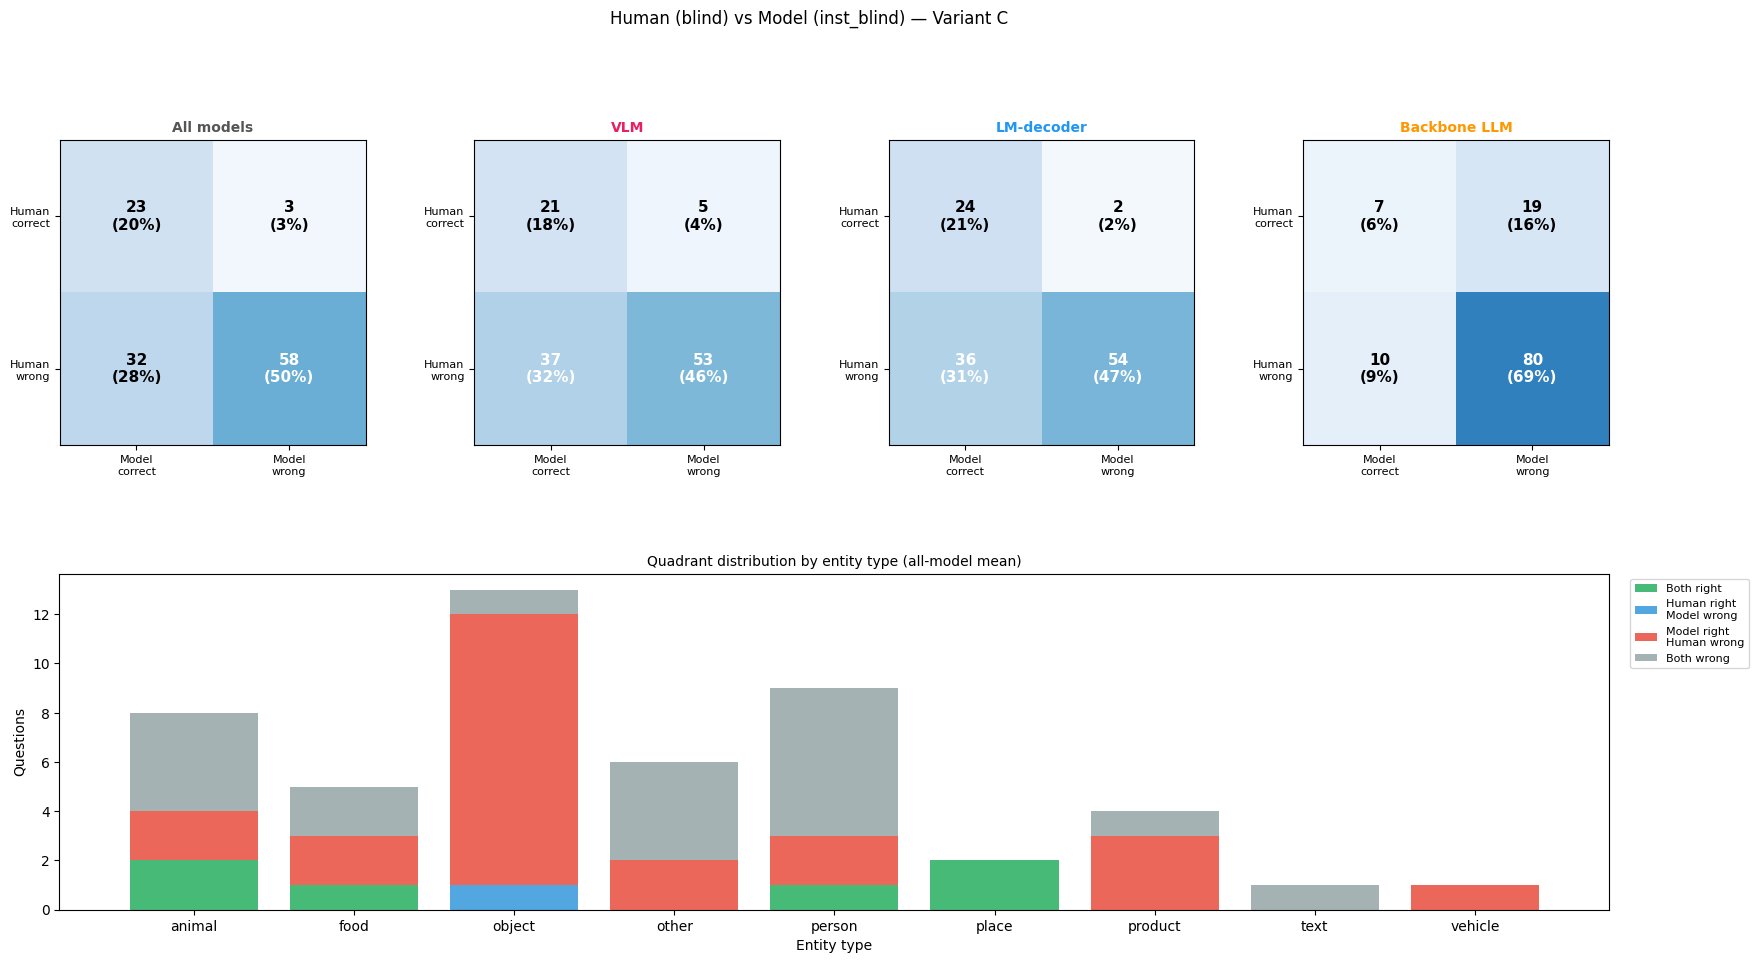

In [11]:
groups = ['All models'] + [g for g in ['VLM', 'LM-decoder', 'Backbone LLM']
                            if any(MODEL_TYPE[l] == g for l in model_q_acc)]

fig = plt.figure(figsize=(5 * len(groups), 10))
gs  = fig.add_gridspec(2, len(groups), height_ratios=[1, 1.1], hspace=0.4, wspace=0.35)

for col, gname in enumerate(groups):
    ax = fig.add_subplot(gs[0, col])
    if gname == 'All models':
        grp_mean_C = model_inst_mean_C
        title, color = 'All models', '#555555'
    else:
        grp_models = [l for l in model_q_acc if MODEL_TYPE[l] == gname]
        grp_mean_C = pd.concat(
            [model_q_acc[l]['C'].rename(l) for l in grp_models], axis=1
        ).mean(axis=1)
        title, color = gname, GROUP_COLORS[gname]

    tmp = cmp[['question_id','human_C']].set_index('question_id').copy()
    tmp['model_C'] = grp_mean_C
    tmp = tmp.dropna()
    tmp['q'] = 'both_wrong'
    tmp.loc[(tmp.human_C >= THR) & (tmp.model_C >= THR), 'q'] = 'both_right'
    tmp.loc[(tmp.human_C >= THR) & (tmp.model_C <  THR), 'q'] = 'human_right'
    tmp.loc[(tmp.human_C <  THR) & (tmp.model_C >= THR), 'q'] = 'model_right'

    cnt = tmp['q'].value_counts(); nn = len(tmp)
    mat = np.array([[cnt.get('both_right',0), cnt.get('human_right',0)],
                    [cnt.get('model_right',0), cnt.get('both_wrong',0)]])
    ax.imshow(mat, cmap='Blues', vmin=0, vmax=nn)
    for i in range(2):
        for j in range(2):
            v = mat[i,j]
            ax.text(j, i, f'{v}\n({100*v/nn:.0f}%)', ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='white' if v > nn*0.3 else 'black')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Model\ncorrect','Model\nwrong'], fontsize=8)
    ax.set_yticklabels(['Human\ncorrect','Human\nwrong'], fontsize=8)
    ax.set_title(title, fontsize=10, color=color, fontweight='bold')

ax2 = fig.add_subplot(gs[1, :])
ent_order = sorted(cmp['ent'].dropna().unique())
bar_data  = cmp.groupby(['ent','quadrant']).size().unstack(fill_value=0)
bar_data  = bar_data.reindex(index=ent_order, columns=quad_order, fill_value=0)
bottoms   = np.zeros(len(ent_order))
for q in quad_order:
    ax2.bar(ent_order, bar_data[q].values, bottom=bottoms,
            color=quad_colors[q], label=quad_labels[q], alpha=0.85)
    bottoms += bar_data[q].values
ax2.set_xlabel('Entity type'); ax2.set_ylabel('Questions')
ax2.set_title('Quadrant distribution by entity type (all-model mean)', fontsize=10)
ax2.legend(fontsize=8, bbox_to_anchor=(1.01,1), loc='upper left')

plt.suptitle('Human (blind) vs Model (inst_blind) — Variant C', y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

## 3a. By Model Group

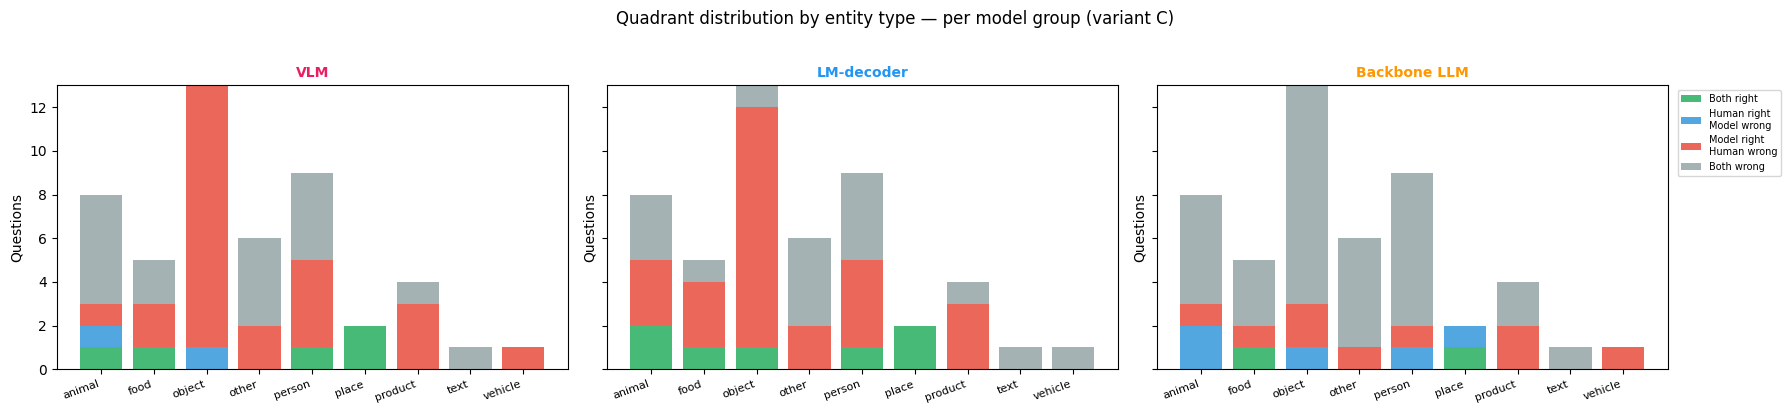

In [12]:
# ── Quadrant distribution by entity type, faceted by model group ─────────────
active_groups = [g for g in ['VLM', 'LM-decoder', 'Backbone LLM']
                 if any(MODEL_TYPE[l] == g for l in model_q_acc)]
ent_order = sorted(cmp['ent'].dropna().unique())
x = np.arange(len(ent_order))

fig, axes = plt.subplots(1, len(active_groups), figsize=(6 * len(active_groups), 4),
                         sharey=True)
if len(active_groups) == 1:
    axes = [axes]

for ax, gname in zip(axes, active_groups):
    grp_models = [l for l in model_q_acc if MODEL_TYPE[l] == gname]
    grp_mean_C = pd.concat(
        [model_q_acc[l]['C'].rename(l) for l in grp_models], axis=1
    ).mean(axis=1)

    tmp = cmp[['question_id', 'human_C', 'ent']].set_index('question_id').copy()
    tmp['model_C'] = grp_mean_C
    tmp = tmp.dropna(subset=['human_C', 'model_C'])
    tmp['q'] = 'both_wrong'
    tmp.loc[(tmp.human_C >= THR) & (tmp.model_C >= THR), 'q'] = 'both_right'
    tmp.loc[(tmp.human_C >= THR) & (tmp.model_C <  THR), 'q'] = 'human_right'
    tmp.loc[(tmp.human_C <  THR) & (tmp.model_C >= THR), 'q'] = 'model_right'

    bd = tmp.groupby(['ent', 'q']).size().unstack(fill_value=0)
    bd = bd.reindex(index=ent_order, columns=quad_order, fill_value=0)
    bottoms = np.zeros(len(ent_order))
    for q in quad_order:
        ax.bar(x, bd[q].values, bottom=bottoms,
               color=quad_colors[q], label=quad_labels[q], alpha=0.85)
        bottoms += bd[q].values

    ax.set_xticks(x)
    ax.set_xticklabels(ent_order, rotation=20, ha='right', fontsize=8)
    ax.set_title(gname, fontsize=10, color=GROUP_COLORS[gname], fontweight='bold')
    ax.set_ylabel('Questions')

axes[-1].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.suptitle('Quadrant distribution by entity type — per model group (variant C)', y=1.02)
plt.tight_layout()
plt.show()


## 3b. By Variant

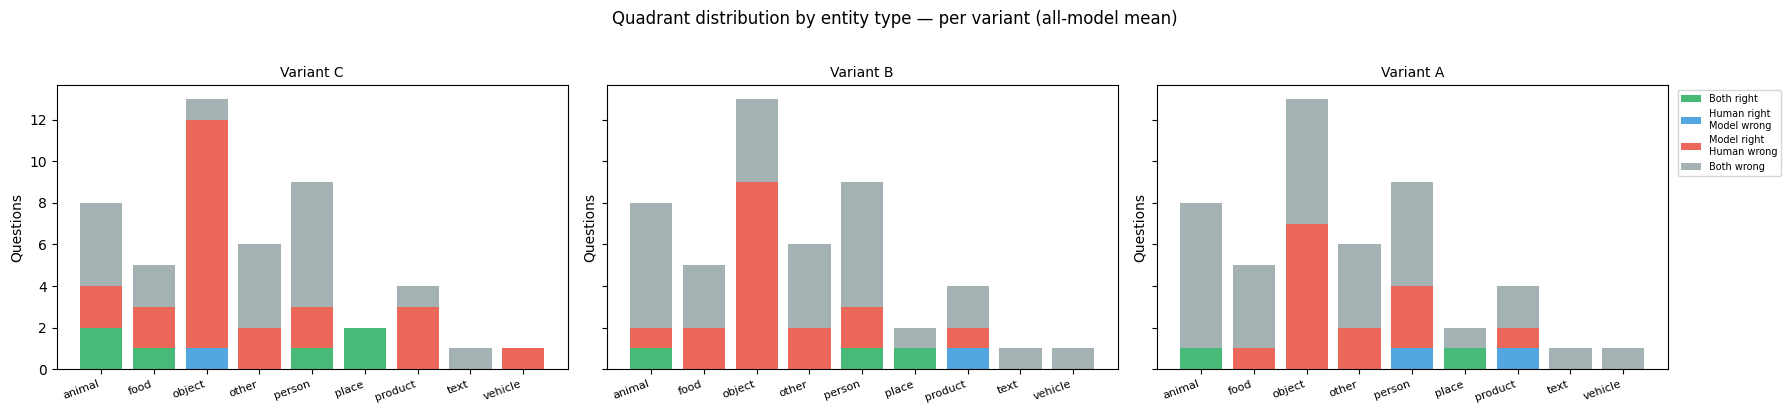

In [13]:
# ── Quadrant distribution by entity type, faceted by variant ─────────────────
# Recompute quadrants for variants B and A using model inst_blind means
ent_order = sorted(cmp['ent'].dropna().unique())
x = np.arange(len(ent_order))

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, var in zip(axes, VARIANT_ORDER):
    model_mean_var = pd.concat(
        [mdf[var].rename(l) for l, mdf in model_q_acc.items()], axis=1
    ).mean(axis=1)

    h_var = df.groupby(['question_id', 'variant'])['accuracy'].mean().unstack()
    h_col = h_var[var] if var in h_var.columns else pd.Series(dtype=float)

    tmp = cmp[['question_id', 'ent']].set_index('question_id').copy()
    tmp['human_v']  = h_col
    tmp['model_v']  = model_mean_var
    tmp = tmp.dropna(subset=['human_v', 'model_v'])
    tmp['q'] = 'both_wrong'
    tmp.loc[(tmp.human_v >= THR) & (tmp.model_v >= THR), 'q'] = 'both_right'
    tmp.loc[(tmp.human_v >= THR) & (tmp.model_v <  THR), 'q'] = 'human_right'
    tmp.loc[(tmp.human_v <  THR) & (tmp.model_v >= THR), 'q'] = 'model_right'

    bd = tmp.groupby(['ent', 'q']).size().unstack(fill_value=0)
    bd = bd.reindex(index=ent_order, columns=quad_order, fill_value=0)
    bottoms = np.zeros(len(ent_order))
    for q in quad_order:
        ax.bar(x, bd[q].values, bottom=bottoms,
               color=quad_colors[q], label=quad_labels[q], alpha=0.85)
        bottoms += bd[q].values

    ax.set_xticks(x)
    ax.set_xticklabels(ent_order, rotation=20, ha='right', fontsize=8)
    ax.set_title(f'Variant {var}', fontsize=10)
    ax.set_ylabel('Questions')

axes[-1].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.suptitle('Quadrant distribution by entity type — per variant (all-model mean)', y=1.02)
plt.tight_layout()
plt.show()


## 4. Example Questions per Quadrant

In [14]:
for q in quad_order:
    sub = cmp[cmp.quadrant == q].sort_values(
        'model_inst_C', ascending=(q in ['both_wrong','human_right']))
    print(f'\n=== {quad_labels[q].replace(chr(10)," ")} (n={len(sub)}) ===')
    for _, row in sub.head(5).iterrows():
        gt = mapper.get_answers(row.question_id)
        print(f'  [{row.ent:8}/{row.op:6}] {str(row.question_en)[:60]}')
        print(f'    GT: {", ".join(gt[:3]) if gt else "?"}  |  human_C={row.human_C:.2f}  model_C={row.model_inst_C:.2f}')


=== Both right (n=23) ===
  [food    /attr  ] What color of wine is in the glasses?
    GT: red, red, red  |  human_C=0.50  model_C=1.00
  [     nan/   nan] Is the girl wearing motorbike boots?
    GT: no, no, no  |  human_C=0.50  model_C=1.00
  [     nan/   nan] Is the woman's top sleeveless?
    GT: yes, yes, yes  |  human_C=0.50  model_C=1.00
  [     nan/   nan] Can one use the fur of these animals to make clothing?
    GT: yes, yes, yes  |  human_C=0.70  model_C=1.00
  [     nan/   nan] Is there broccoli in the mixture?
    GT: no, no, no  |  human_C=0.77  model_C=0.96

=== Human right Model wrong (n=3) ===
  [     nan/   nan] How many of these people are female?
    GT: 3, 2, 2  |  human_C=0.50  model_C=0.17
  [     nan/   nan] How many hot dogs are on this bun?
    GT: 2, 2, 1  |  human_C=0.60  model_C=0.25
  [object  /attr  ] What is the bowl made of?
    GT: pottery, ceramic, ceramic  |  human_C=0.67  model_C=0.42

=== Model right Human wrong (n=32) ===
  [product /ident ] Wha

## 5. Export CSV

In [ ]:
# ── Export: one CSV with quadrant labels + human + model answers/accuracy ─────
from collections import Counter

EXPORT_PATH = BASE / 'analysis/session2/examples/quadrant_full.csv'
EXPORT_PATH.parent.mkdir(exist_ok=True)

CT = {'C': 'question', 'B': 'weaker_object', 'A': 'pronominalized'}

# ── Load raw model answers (inst_blind) ───────────────────────────────────────
raw_answers = {}  # label → {(qid, var): answer_str}
for label, (rdir, mdir) in ALL_MODELS.items():
    path = rdir / mdir / 'vqa_1k_control_inst_blind.jsonl'
    if not path.exists(): continue
    raw_answers[label] = {}
    for line in open(path):
        ex  = json.loads(line)
        qid = int(ex['question_id'])
        if qid not in q_ids: continue
        for var, ct in CT.items():
            ans = _clean_answer(ex.get('generated_answers', {}).get(ct, ''))
            if ans:
                raw_answers[label][(qid, var)] = ans

# ── Helper: quadrant label for a given question + model-mean series ───────────
def get_quad(qid, h_col, model_series):
    h = h_col.get(qid, float('nan'))
    m = model_series.get(qid, float('nan'))
    if pd.isna(h) or pd.isna(m): return ''
    if h >= THR and m >= THR: return 'both_right'
    if h >= THR and m <  THR: return 'human_right'
    if h <  THR and m >= THR: return 'model_right'
    return 'both_wrong'

# ── Precompute model means per group and variant ──────────────────────────────
h_by_var = {var: df[df.variant == var].groupby('question_id')['accuracy'].mean()
            for var in VARIANT_ORDER}

model_means = {}   # (group, var) → Series
for var in VARIANT_ORDER:
    model_means[('all', var)] = pd.concat(
        [mdf[var].rename(l) for l, mdf in model_q_acc.items()], axis=1
    ).mean(axis=1)
    for gname in ['VLM', 'LM-decoder', 'Backbone LLM']:
        grp = [l for l in model_q_acc if MODEL_TYPE[l] == gname]
        if grp:
            model_means[(gname, var)] = pd.concat(
                [model_q_acc[l][var].rename(l) for l in grp], axis=1
            ).mean(axis=1)

# ── Build one row per question ────────────────────────────────────────────────
rows = []
for qid in sorted(q_ids):
    gt = mapper.get_answers(qid)
    row = {
        'question_id':  qid,
        'question_en':  q_text.get(qid, ''),
        'ent':          s2.set_index('question_id').loc[qid, 'ent'] if qid in s2['question_id'].values else '',
        'op':           s2.set_index('question_id').loc[qid, 'op']  if qid in s2['question_id'].values else '',
        'gt':           ', '.join(gt[:5]) if gt else '',
    }

    # ── Human: aggregate answers + accuracy per variant ───────────────────────
    for var in VARIANT_ORDER:
        sub = df[(df.question_id == qid) & (df.variant == var)]
        ans_counts = Counter(sub['answer_en'].str.lower().str.strip())
        row[f'human_{var}_answers'] = ' | '.join(f'{a}({n})' for a, n in ans_counts.most_common(5))
        row[f'human_{var}_acc']     = round(sub['accuracy'].mean(), 3) if len(sub) else ''

    # ── Model: answer + accuracy per model per variant ────────────────────────
    for label in ALL_MODELS:
        if label not in model_q_acc: continue
        short = label.replace('LLaVA-', '').replace('Qwen3-VL-', 'Q3VL-')
        for var in VARIANT_ORDER:
            ans = raw_answers.get(label, {}).get((qid, var), '')
            acc = model_q_acc[label].loc[qid, var] if qid in model_q_acc[label].index else float('nan')
            row[f'{short}_{var}_answer'] = ans
            row[f'{short}_{var}_acc']    = round(acc, 3) if not pd.isna(acc) else ''

    # ── Quadrant labels: all-model mean per variant ───────────────────────────
    for var in VARIANT_ORDER:
        h_col = h_by_var[var]
        row[f'quadrant_{var}'] = get_quad(qid, h_col, model_means[('all', var)])

    # ── Quadrant labels: per model group (variant C only) ────────────────────
    for gname in ['VLM', 'LM-decoder', 'Backbone LLM']:
        key = (gname, 'C')
        if key in model_means:
            col_name = 'quadrant_C_' + gname.replace(' ', '_').replace('-', '_')
            row[col_name] = get_quad(qid, h_by_var['C'], model_means[key])

    rows.append(row)

out = pd.DataFrame(rows)
out.to_csv(EXPORT_PATH, index=False)
print(f'Saved {len(out)} rows, {len(out.columns)} columns → {EXPORT_PATH}')
print('Columns:', list(out.columns))
